In [1]:
#| output: false

import sys
sys.path.append('..')
from Edinburgh_Model.model import *

from Scripts import summary
from Scripts import trape
from Scripts import goncalves
from Scripts import natama
from math import log

# default model parameters
pars = Parameters()

# posterior draws
trape_mu, trape_sigma = trape.get_estimates('../Data_Fitting/Trape/trape8_draws.csv')
goncalves_est = goncalves.get_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')
malaria = natama.last_day_of_season()[2]

# Clinical episodes with detectable parasites in the rabies and delayed arm of the RH5.1 trial
D_r = malaria['rabies']
D_d = malaria['delayed']


# Introduction

Current state-of-the-art epidemiological models of malaria and its interventions are complex, individual-based models with large numbers of parameters that require a deep knowledge of mathematical modelling and expert computational skills to use [@galactionova_insights_2021]. Our motivation is to develop a small, deterministic, population-based model with a minimal number of parameters, all estimated from empirical data, that explain age patterns of clinical malaria, severe malaria and deaths across transmission intensities and in stable transmission settings. We also require that the model provide fast simulations for responsive visualisations for a public website. The website is designed to allow non-modelling scientists to explore the sensitivity of age patterns to changes in parameter values and different intervention strategies. 

In this notebook we summarise the main aspects of our model. In the accompanying notebooks we describe the development and justification of the model in more detail.

As with all malaria epidemiological models, ours is a simplification of the highly complex processes underlying malaria transmission, disease, immunology and control. Therefore, numerical results should *not* be interpreted as accurate predictions, but rather as providing qualitative insights for informing vaccine development, clinical trial design and implementation of vaccine programmes. Models such as ours clarify understanding about relationships between malaria immunology and epidemiology and vaccine characteristics and their implementation [@halloran_modeling_1989]. And they allow us to ask, What if? questions. 

# Demography

The model follows a single multi-age cohort of people weekly from birth till last death. This is in contrast to other malaria intervention modelling studies which follow a multi-cohort population of individuals maintained at constant size by births and deaths (see [Notebook S2](S2_cohort_vs_population.ipynb) for our justification for taking this approach). 

All-cause, age-specific CFR in the cohort are calculated from the Tanzania 2019 life table (@fig-survival). As most severe malaria episodes and malaria-associated deaths occur in the under fives, modelling all-cause mortality till old age is not really necessary. We include it to avoid having to set an arbitrary upper age limit (as is done in other studies, e.g. @penny_public_2016) and to accurately calculate lifetime clinical, severe and fatal cases. 

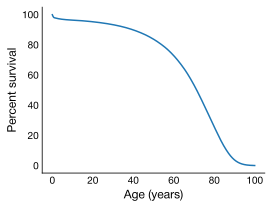

In [2]:
#| label: fig-survival
#| fig-cap: "Survival function of cohort based on the 2019 Tanzania life table."

fig, ax = summary.tanzania_all_cause_mortality()

# Independent blood-stage infection rate as a measure of transmission intensity

The field studies that we use to parameterise our models of clinical and severe malaria immunity intensively monitored their populations with active and passive surveillance [@trape_1996; @goncalves_parasite_2014; @trape_one_2024]. Clinical attacks were immediately drug treated, which means that most were likely to be from acute infections rather than recrudescences of earlier infections.

Our models of the development of clinical and severe malaria immunity are based on exposure, defined as the cumulative number of independent blood-stage infections. This definition is useful for comparing interventions that have different modes of action (i.e. some block blood-stage infections and others do not).

Defining what is an "independent blood-stage infection" is not trivial, however. We adopt the following definition which is a compromise between uncertainty in our understanding of the determinants of naturally acquired immunity, mathematical precision and the practicalities of measuring independent blood-stage infections in the field:

1. an acute period of parasitaemia that leads to clinical disease, which may either (a) be drug-treated or (b) progress to severe malaria
or
2. a prolonged period of parasitaemia that is asymptomatic then cleared naturally or incidentally with drugs.

Each of these can be a clonal or multi-genotype infection, and the latter may arise from one or more mosquito bites. Furthermore, (1) may overlap with (2) due to superinfection, but not due to recrudescence. Nevertheless, in every case an independent blood-stage infection contributes equally toward the development of immunity (i.e., clonality,  length of infection and cumulative parasite load are unimportant in the model, cf. @maire_model_2006 and @eckhoff_malaria_2012). 

Given this, it makes sense to use the rate of independent blood-stage infections as a measure of transmission intensity. To this end, we use annual average number of independent blood-stage infections per child. Other modelling studies (e.g., @penny_public_2016), use EIR as a measure of transmission intensity. But this introduces additional model parameters to convert from EIR to independent blood infection rate [@smith_relationships_2004]; and we are trying to minimise the number of parameters in the model.

Below we discuss further our rationale for using independent blood-stage infections as a measure of transmission intensity.

## Biological plausibility: clinical immunity is primarily disease-modifying, not infection-blocking

Epidemiological evidence indicates that individuals in endemic settings often acquire protection against clinical malaria without acquiring sterilising immunity against infection. For example, in Mali, @tran_intensive_2013 showed that the risk of acquiring PCR-detectable blood-infection did not fall with age, whereas the risk of clinical malaria did. Which implies that immunity reduces symptoms given a blood infection rather than preventing infection outright. In a Kenyan cohort designed to separate immunity from absence of exposure, @bejon_analysis_2009 similarly observed an age-related shift from febrile malaria to asymptomatic parasitaemia without a corresponding reduction in infection incidence.

If immunity acts mainly by reducing the probability of clinical disease conditional on infection, then the natural “dose counter” for immunity building is not the cumulative number of infectious bites, but the cumulative number of blood-stage infections that successfully establish. This motivates cumulative blood-stage infections as a predictor for temporal immunity acquisition and blood-stage infection rate as a natural and simple measure of transmission intensity.

## Empirical support: prior blood-stage infections predict reduced clinical risk upon infection

Quantitative support for using cumulative blood-stage infections comes from studies that jointly estimate exposure heterogeneity and immunity effects. 

In a long-running Senegalese cohort study in Dielmo village, @trape_1996 showed that in this very high transmission site (annual EIR on the order of hundreds of infective bites per person per year), clinical attack rates were highest in early childhood and then fell steeply with increasing age and exposure, becoming rare in adults despite ongoing transmission — a pattern most parsimoniously explained by immunity accrued through repeated blood-stage infections rather than by calendar time alone. 

In their updated multi-decade follow-up, @trape_one_2024 documented that as control reduced transmission intensity, the burden of clinical malaria shifted towards older children (and occasionally adults) during low-transmission periods, consistent with slower accumulation (and potential waning) of clinical immunity when independent blood-stage infections are fewer. This “age shift" under reduced exposure is exactly what one would predict if the relevant state variable for disease-modifying immunity is the cumulative number of independent blood-stage infections rather than age alone.

In a high-transmission Ugandan cohort with intensive follow-up, @rodriguez-barraquer_quantifying_2016 estimated that the risk of developing clinical malaria upon infection declined with both age and the cumulative number of prior infections, with an average reduction of ~2% per additional prior infection and ~6% per additional year of age. (Their conclusion of a significant age effect is not adequately supported, though, because (i) their exposure-only model (c2) had lower DIC than their age-only model (c1) and their exposure+age model (c1a) had the same DIC as their exposure-only model (c2) and (ii) in their models adjusted for treatment, no comparison between exposure-only and age-only models was made (their Table S2).)

## Interventions that reduce blood-stage infections delay clinical immunity

Chemoprophylaxis and other exposure-reducing interventions function as experiments that manipulate cumulative blood-stage infections. If cumulative blood-stage infections drive clinical immunity acquisition, then suppressing blood-stage infections should delay immunity and produce a transient rebound in morbidity. For example, in Tanzanian infants receiving prophylaxis in the first year of life, @aponte_age_2007 found large reductions in clinical malaria during prophylaxis, followed by rebound of clinical malaria for about two years after stopping.  In The Gambia, @greenwood_mortality_1995 observed increased clinical attacks in the year after stopping long-term chemoprophylaxis.  

## Why blood infections rather than inoculations: force-of-infection saturates relative to EIR

Several modelling studies demonstrate that the force of infection increases sub-linearly with EIR because (i) some sporozoite inoculations fail to establish blood-stage infection and (ii) heterogeneity in biting concentrates exposure in a few individuals. @smith_relationships_2004 have argued that EIR is a poor indicator of infection rate across ages and across populations. 

Because clinical immunity is driven by the experience of blood-stage infection, cumulative blood-stage infections provides a more proximal predictor than cumulative inoculations. 

## Consistency with mechanistic formulations of clinical immunity in transmission models

Many malaria transmission models represent clinical immunity as a function of cumulative exposure, sometimes using explicit immunity variables that increase with parasite densities or infection events and decay over time [@penny_public_2016]. Within OpenMalaria, clinical disease arises via a pyrogenic threshold that responds dynamically to parasite load, and immunity components are calibrated to reproduce age- and exposure-dependent patterns of clinical incidence [@smith_relationship_2006; @maire_predictions_2006; @ross_epidemiologic_2006]. While these models often use cumulative parasite density or “time infected” internally, they support the same conceptual structure: repeated blood-stage infections produce gradual reductions in clinical risk.

Empirically, @smith_relationships_1998 reported that clinical incidence in very young Tanzanian children decreased steeply with estimated cumulative time infected with trophozoites, rather than with estimated cumulative inoculations since birth. Cumulative blood-stage infections is not identical to cumulative time infected, but under broadly stable infection durations and frequent reinfection, the count of independent blood-stage infections is a pragmatic proxy for cumulative antigenic and inflammatory experience in blood-stage. Importantly, cumulative infections is also easier to define consistently across cohorts than integrals of (often imperfectly detected) parasitaemia. More importantly, length of infection implies that a single chronic infection would generate the same level of immunity as repeated acute infections. there is no evidence to support this, and it is biologically unlikely.

## Counting independent blood infection rates in the field

The problem with using independent blood infections as transmission intensity is that these are not so easily counted in the field if surveillance is not active and frequent, infection is confirmed by only microscopy and not by more sensitive methods such as qPCR and presentation is not immediately followed by drug treatment clearing 100% of parasites. So translating our model outputs, which are in terms of independent blood infections, to field conditions needs care.

Having said that, our key results and conclusions concern independent blood infection rates below about 3 per year. Below this threshold, and in populations with comprehensive drug treatment upon clinical presentation, our modelling has shown that there is an almost linear relationship of about 1 annual clinical attack in the under fives for about every 2 annual independent blood-stage infections (Notebook S11). Thus counting average annual clinical attacks in the under fives may give a reasonable indication of the average annual blood-stage infection rate. 



# Our model of infection, disease and death

An infectious bite can lead to a liver infection which can lead to a blood-stage infection. We are not modelling the insect vector population, nor transmission between hosts. As current vaccines target young children under five, they are unlikely to affect transmission rate as pre-school children contribute minimally to the transmission reservoir [@galactionova_insights_2021]. In this study, therefore, we are not modelling vaccine-induced changes in transmission intensity. We do not model infection blocking immunity as that develops relatively slowly and only in those with very high cumulative exposure [@maire_model_2006]. This means we can ignore transmission and pre-erythrocytic infections and focus solely on blood-stage infections. @fig-model illustrates our model of the time course from infectious bite to potential death.

:::{#fig-model}
![](Figures/model.svg){height=30% fig-align="center"}

Time course of a malaria infection. Once established, a blood-stage infection may resolve without disease (uncomplicated malaria) or may progress to clinical disease (i.e., fever). It may then resolve or progress to severe malaria which may then be fatal.
:::

Let $\lambda$ be the population-average annual blood infection rate per child. Time is discretised in to one-week intervals. In each week the model calculates the number of new blood-stage infections in children of age $a$ who have previously experienced $n$ blood-stage infections. Blood infection rate is modified by one or more of the following:

1. seasonal changes in infection rate
2. heterogeneity in bite rate/susceptibility to blood infection(these are epidemiologically equivalent in terms of modifying blood infection rate)
3. early life protection from, for example, maternal antibodies and reduced bite rate due to smaller body surface area relative to adults
4. protection derived from interventions such as vaccination and chemoprevention

Seasonal variation in blood-stage infection rate is modelled using the circular Von-mises distribution with configurable mean and variance to model different timings and lengths of the malaria season. See [Notebook S3](S3_season_length.ipynb) for more details.

Heterogeneity in relative bite rate/host susceptibility to blood infection is modelled by a symmetric triangular distribution centred on one. In contrast, @smith_entomological_2005 suggested a Gamma distribution. However, the unconstrained upper bound of the Gamma distribution introduces numerical instabilities. So, for pragmatic reasons, we use the constrained triangular distribution based on Figure 3A of @rodriguez-barraquer_quantifying_2016.   

Early in life children are at less risk of a blood infection than older children. They are protected from blood infection by maternal antibodies, and their smaller body surface area means they are less likely to be bitten by mosquitoes (see Figures 1 of @smith_relationships_2004 and @smith_epidemiologic_2006). We could model maternal antibody and body surface area protection separately, as the WHO consensus models did [@penny_public_2016]. But to keep the model as simple as possible we combine them into a single "early-life protection factor" against blood-stage infection. This assumption is supported by our modelling of clinical episodes in two Senegal villages, Dielmo and Ndiop ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024). We assume that relative early life protection decays exponentially from a maximum of $\rho_\text{elp}$ at age zero and with a half-life of $\tau_\text{elp}$:

$$\text{Relative protection from blood-stage infection at age $a$} = \rho_\text{elp} \exp\left(-\frac{\ln 2}{\tau_\text{elp}}a\right)$$

This simple model fitted the data from the two villages very well with estimates $\rho_\text{elp} =$ `{python} f'{trape_mu["rho_elp"]:.2f}'` $\pm$ `{python} f'{trape_sigma["rho_elp"]:.2f}'` and $\tau_\text{elp}=$ `{python} f'{trape_mu["tau_elp"]:.2f}'` $\pm$ `{python} f'{trape_sigma["tau_elp"]:.2f}'` years. That is, newborns are at `{python} f'{pars.ρ_elp:.0%}'` less risk of blood-stage infection than adults, and risk of blood infection doubles roughly every `{python} f'{pars.τ_elp:.1f}'` years in childhood.

# Disease

In our model, a blood-stage infection can either progress to febrile disease (clinical episode) or is asymptomatic and cleared naturally or incidentally drug-treated. Based on our modelling of data in @goncalves_parasite_2014 (see [Notebook S4](S4_goncalves.ipynb)), we estimate that `{python} f'{1-goncalves_est.P_fever.mean():.1%} ± {goncalves_est.P_fever.std():.1%}'` of blood-stage infections are asymptomatic. @griffin_estimates_2014 and @henry_infection_2022 estimate very similar values. 

A clinical episode may then progress to become severe using the WHO definition of severe disease or is drug-treated. We do not distinguish between the various syndromes of severe disease. A severe episode may lead to death (see below).

We assume that only one clinical episode can occur per infection. This, of course, is not always true. But @smith_relationships_2004 have argued: *"There is strong evidence both from molecular typing and from patterns of seasonality in morbidity that clinical malaria is normally caused by newly invading parasites, and the most severe symptoms generally accompanying the first peak of parasite density after infection."* 

# Death

There is much qualitative and quantitative uncertainty about malaria associated deaths. Therefore, all models' predictions are subject to considerable uncertainty. Consensus modelling, in which the outputs of different models with different underlying assumptions are compared, is a standard method to mitigate against some of this uncertainty [@penny_public_2016]. But even when models agree, this method is no guarantee that the consensus output is an accurate reflection of reality if model assumptions and parametrisations are inaccurate.   

It has been argued that there are two major causes of malaria-associated deaths: directly attributable deaths due to severe malaria, and indirectly attributable deaths that would be prevented in the absence of a malaria infection due to co-morbidities [@molineaux_malaria_1997; @ross_epidemiologic_2006].

Of the WHO consensus models, only OpenMalaria models both of these causes [@penny_public_2016]. We tried to implement indirect deaths using the model of @ross_epidemiologic_2006, but were unable to match the output of our model to the shape of the all-cause mortality data presented in their Figure 9. In addition, including indirect deaths does not match age-patterns observed from verbal autopsy reports [@abdullah_patterns_2007]. We therefore decided not to implement indirect deaths.

We base our model of age-specific, severe-case fatality risk (CFR) on a comprehensive study of severe malaria and mortality in almost 2,000 hospital admissions in multiple sites spanning substantially different transmission intensities [@reyburn_association_2005]. This dataset allows us to quantify the risk that a severe episode becomes fatal. The authors made two important conclusions relevant to our work: first, CFR is age-specific, and second, CFR is independent of transmission intensity. This allows us to assume that CFR is independent of average annual blood-stage infection rate, $\lambda$.

Our analysis of this data is detailed in [Notebook S7](S7_cfr.ipynb) and the resulting CFR curve is shown in @fig-cfr. In our model we use the mean risk, which is represented by the dashed blue line, and examine the sensitivity of our conclusions to changes in the strength of age-specificity in [Notebook 10](S10_sensitivity_analysis.ipynb). 

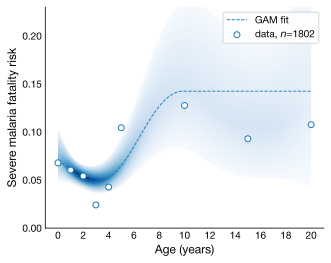

In [3]:
#| label: fig-cfr
#| fig-cap: "Hospitalised, severe malaria cases and resulting fatalities by age from @reyburn_association_2005 were fitted by logistic GAM. Open circles: age-stratified CFR calculated from the *n*=1802 severe cases. Shaded blue band: 95% CI of the GAM-estimated age-specific CFR. Dashed blue line: the estimated mean CFR from 0-10 years of age, from age 10+ we assume a constant CFR as the GAM estimate becomes unreliable due to very few adult deaths. Note, the GAM is fitted to the full set of severe cases, not the age-stratified risks shown as open circles."

from Scripts import reyburn
gam = reyburn.fit_GAM()
XX, fit, cfr, cis = reyburn.cfr_mean_CI(gam)
fig, ax = reyburn.plot_GAM_mean_CI_data(XX, fit, cfr, cis)

A similar pattern of age-specific mortality has been reported by @marsh_malaria_1999 with risk falling from about 5% in newborns to about 2.5% after two years of life, then rising to about 5% in 5-9 year olds.

These patterns are in concordance with data that support the conclusion that cerebral malaria is comparatively rare in infancy, more common in older children [@marsh_indicators_1995; @marsh_k_host-parasite_1997], and associated with markedly elevated mortality of around 15-20% [@marsh_indicators_1995; @idro_severe_2006; @moxon_new_2020].

OpenMalaria also use this data [@ross_epidemiologic_2006]. The Imperial model inferred age-specific CFR by using data on severe malaria syndromes. Their estimated CFR, though, is almost flat, resulting in an almost constant CFR with age (see Figure 3D in @griffin_gradual_2015). The other two WHO consensus models do not use age-specific CFR [@penny_public_2016].

# Naturally acquired immunity

Levels of immunity (naturally acquired or by immunisation) are represented as across-cohort averages in our model. 

@fig-immunity illustrates the two types of malaria immunity and their affect on the progression of infection and disease that we include in our model. We do not model pre-erythrocytic, infection blocking immunity as it develops relatively slowly and only in those with very high exposure [@maire_predictions_2006; @bejon_analysis_2009; @tran_intensive_2013]. Neither do we model protective immunity against gametocytes as we are not modelling between-host transmission.

:::{#fig-immunity}
![](Figures/natural_immunity.svg){height=30% fig-align="center"}

The modelled types of malaria immunity and where they impact disease progression.
:::

As discussed above, previous models have assumed that blood-stage infection is the main driver of naturally acquired immunity [@penny_public_2016]. They all assume that protection increases with each blood-stage infection. Some models also assume that protection increases with cumulative parasitaemia (OpenMalaria) or age (Imperial). Apart from the GSK model, the other WHO consensus models also assume that immunity can decay between infections. 

We do not model immunity per se. Instead, we model the risk of clinical malaria given a blood-stage infection and the risk of a clinical episode becoming severe. We assume that the risk of clinical malaria decays with the cumulative number of blood-stage infections. And we assume that the risk of a clinical episode becoming severe decays with age-dependent exposure. Between infections risk is assumed to remain constant, i.e., there is no decay in immunity. 

## Naturally acquired immunity to clinical malaria

We tested several models of the reduction in risk of clinical malaria with exposure (see [Notebook S5](S5_clinical_immunity.ipynb)). We used clinical attack rate data from two Senegalese villages: Dielmo and Ndiop. These populations have been uninterruptedly followed with identical and strict clinical surveillance programs. These include daily home visits to each person and the 24h presence of medical teams in the villages to diagnose and treat any pathological episode [@trape_1996; @trape_one_2024]. Thus these datasets are of very high quality. We found that a sigmoidal decay with exposure gives excellent fits to individual-level data from Dielmo village and population-level data from both Dielmo and Ndiop. The form of the decay is given by the equation:

$$\text{Pr(clinical episode on $n^\text{th}$ blood infection)} = \rho_\text{clinical}\frac{e^{\delta_\text{clinical}[\gamma_\text{clinical}-1]}-1}{e^{\delta_\text{clinical}[\gamma_\text{clinical}-1]}-2+e^{\delta_\text{clinical}[n-1]}}$$

where $\rho_\text{clinical}$ is the risk on first blood infection, $\gamma_\text{clinical}$ is the number of blood infections at half-maximum-risk, i.e., when $n=\gamma_\text{clinical}$, risk is $\frac{\rho_\text{clinical}}{2}$, and $\delta_\text{clinical}$ is proportional to the decay rate of risk with the number of infections at $n=\gamma_\text{clinical}$.

There are identifiability problems between the estimates of most of the model parameters due to our broad priors and the nature of fitting a nonlinear model to the clinical age patterns ([Notebook S5](S5_clinical_immunity.ipynb)). We therefore used our very precise estimate for the probability of a blood infection becoming clinical (`{python} f'{goncalves_est.P_fever.mean():.3f} ± {goncalves_est.P_fever.std():.3f}'`) from our analysis of data from @goncalves_parasite_2014 as a very informative prior and refitted the above model. (This parameter is not equivalent to $\rho_\text{clinical}$ because it is an average over two years of infections, however, due to the slow development of clinical immunity it is a reasonable alternative.)

The fits of the model to the observed annual clinical attacks rates are shown in @fig-population_fit.

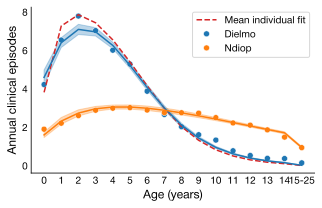

In [4]:
#| label: fig-population_fit
#| fig-cap: "Fits of the clinical attack rate model to age-stratified data from Dielmo and Ndiop villages. Circles are observed annual clinical attack rates. Posterior mean age patterns and their 95% credible intervals are represented by the lines and shaded regions. The red dashed line is the prediction using the mean parameter estimates from the fit to the individual-level data of Dielmo village."

pars_dielmo, pars_ndiop, df = trape.get_population_pars_homo('../Data_Fitting/Trape/trape8_draws.csv')
fig, axs = trape.fit_pop_model(pars_dielmo, pars_ndiop, '../Data_Fitting/Trape/trape4_fit.pickle', 'Data/trape_site_rates.csv')

The estimated risk curve is shown in @fig-clinical-risk. The parameter estimates used in the model are $\rho_\text{clinical}=$ `{python} f'{trape_mu["rho_clinical"]:.2f}'`  $\pm$ `{python} f'{trape_sigma["rho_clinical"]:.2f}'`, $\gamma_\text{clinical}=$ `{python} f'{trape_mu["gamma_clinical"]:.0f}'`  $\pm$ `{python} f'{trape_sigma["gamma_clinical"]:.0f}'` blood infections and $\delta_\text{clinical}=$ `{python} f'{trape_mu["delta_clinical"]:.3f}'`  $\pm$ `{python} f'{trape_sigma["delta_clinical"]:.3f}'` per blood infection.

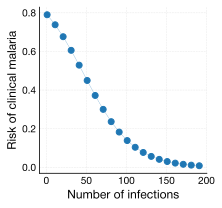

In [5]:
#| label: fig-clinical-risk
#| fig-cap: "Estimated decline in risk of a blood infection becoming clinical with exposure."

fig, ax = summary.clinical_malaria_risk_plot()

## Naturally acquired immunity to severe malaria

Although it is accepted that immunity against severe malaria develops more rapidly than immunity against clinical disease, there is still controversy about how rapidly it develops. @baird_age-dependent_1998 has shown that non-immune adults develop immunity against delirium or loss of consciousness (measured by the number of medical evacuations) within 4 months of migrating to a hyperendemic malaria region. @gupta_acquired_1999 estimated immunity developing after one or two infections based on model fitting to incidence of severe disease in hospital admissions in The Gambia and Kenya across a range of transmission intensities. @munoz_sandoval_plasmodium_2025 analysed data from @goncalves_parasite_2014 to demonstrate that the risk of severe malaria decays at a rate of 0.12 per blood infection: a half-life of 5.7 infections. In contrast, @griffin_gradual_2015 suggest that the risk of severe malaria depends on EIR: At low EIR risk declines rapidly with exposure, but at high EIR risk rises slowly then declines slowly with exposure over a few decades.

We initially used the @munoz_sandoval_plasmodium_2025 model:

$$\text{Pr(clinical episode becomes severe on $n^\text{th}$ blood infection)} = \rho_\text{severe}e^{-\delta_\text{severe}[n-1]}$$

where $\rho_\text{severe}$ is the risk on first blood infection and $\delta_\text{severe}$ is the rate of decline in risk with exposure. We re-estimated these parameters using the data from @goncalves_parasite_2014. They recorded all infections and severe malaria episodes in a cohort of 882 children from birth till two to four years old in Tanzania from 2001-2004. Our analysis in [Notebook S4](S4_goncalves.ipynb) is a more comprehensive analysis of the data than was performed in @munoz_sandoval_plasmodium_2025, although the results are very similar. We estimated the average risk on first blood infection to be $\rho_\text{severe}=$ `{python} f'{goncalves_est.P_severe.mean():.1%} ± {goncalves_est.P_severe.std():.1%}'` and the average decay in risk to be $\delta_\text{severe}=$ `{python} f'{goncalves_est.dS.mean():.2f} ± {goncalves_est.dS.std():.2f}'` per blood infection — which corresponds to a halving of risk every `{python} f'{log(2)/goncalves_est.dS.mean():.1f}'` blood infections. However, this half-life might be an overestimate due to amodiaquine treatment failure causing recrudescent infections to be counted as new acute infections. @goncalves_parasite_2014 reported amodiaquine 28-day failure rate of at least 52%. Another study put the 28-day failure rate in Tanzania in 2005 at 76% [@mutabingwa_amodiaquine_2005]. We examine this uncertainty in [Notebook S10](S10_sensitivity_analysis.ipynb).

However, as discussed in [Notebook S6](S6_severe_malaria_immunity.ipynb), this model of severe malaria risk is not entirely consistent with other severe malaria and mortality age-pattern datasets. In particular, at low transmission intensities severe episode rate and mortality rate remain high into the teens causing a second peak in deaths ([@fig-initial_consequences]) due to rising CFR with age after age four (@reyburn_association_2005; [Notebook S7](S7_cfr.ipynb)). This causes long-term cumulative deaths to rise with declining transmission intensity: a pattern not seen in the epidemiological data [@abdullah_patterns_2007]. 


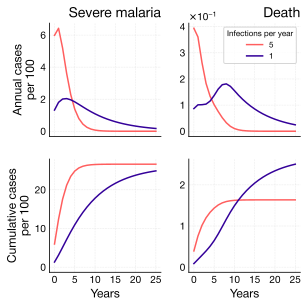

In [6]:
#| label: fig-initial_consequences
#| fig-cap: "Severe malaria and mortality rates and cumulative episodes for 1 and 5 blood infections per year assuming exposure-only dependent reduction in risk of severe malaria."

from Scripts import paper
fig, axs = paper.unvaccinated(λs=(5, 1), popsize=100, ε_severe=0, years=26, fig_xscale=0.75, fig_yscale=0.75, vars=[]);

To overcome this discrepancy we propose a modified model with risk reducing with age-dependent exposure:

$$\text{Pr(clinical episode becomes severe on $n^\text{th}$ blood infection at age $a$)} = \rho_\text{severe}e^{-[\delta_\text{severe} + \epsilon_\text{severe}a][n-1]}$$

where $\epsilon_\text{severe}$ modifies the reduction in risk of severe malaria with age $a$. In [Notebook S6](S6_severe_malaria_immunity.ipynb) we show that a value of $\epsilon_\text{severe}=$ `{python} f'{pars.ε_severe:.3f}'` per blood infection per year is sufficient to suppress the second peak in deaths and makes long-term cumulative deaths fall with falling transmission intensity ([@fig-modified_model]) as is reported in the literature [@abdullah_patterns_2007].

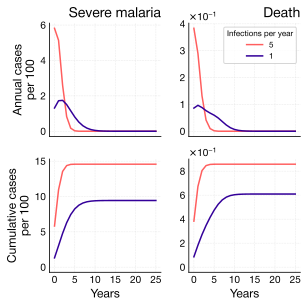

In [7]:
#| label: fig-modified_model
#| fig-cap: "Severe malaria and mortality rates and cumulative episodes for 1 and 5 blood infections per year with the modified model of severe malaria risk reducing with age-dependent exposure."

fig, axs = paper.unvaccinated(λs=(5, 1), popsize=100, years=26, fig_xscale=0.75, fig_yscale=0.75, vars=[]);

The resulting risk curves are shown in @fig-severe_malaria_risk. Irrespective of age, the risk of a clinical episode on first blood infection becoming severe is `{python} f'{goncalves_est.P_severe.mean():.1%}'`. However, older children with the same number of blood infections as younger children are at less risk of severe malaria.

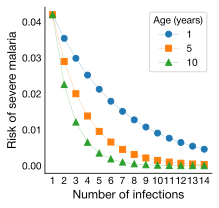

In [8]:
#| label: fig-severe_malaria_risk
#| fig-cap: "Risk of a clinical episode becoming severe depends on age and exposure."

fig, ax = summary.severe_malaria_risk_plot()

# Other model assumptions

Model assumptions that differ from the WHO consensus models. We do not model:

1. super-infections,
2. a delay from infection to occurrence of symptoms and death as this has no impact on long-term dynamics,
3. within-host parasite density,
5. duration of infection, therefore we do not predict prevalence, only incidence.

# Definition of averted cases and vaccine efficacy

In malaria vaccine clinical trials, and modelling studies of those trials, vaccine efficacy is usually calculated from the last primary dose onwards. We take the same approach here because of lack of data and the large uncertainty in estimating partial protection before the last primary dose. In other words, we do not model partial protection before the last primary dose and we start counting blood-stage infections, clinical and severe malaria episodes and deaths in the unvaccinated and vaccinated cohorts immediately after the last primary dose.

The time-dependent number of averted cases is therefore

$$\text{cases averted}(t) = \text{cumulative unvaccinated cases}(t) - \text{cumulative vaccinated cases}(t)$$

where $t=0$ is the day of the last primary dose in the vaccinated cohort. This equation applies to blood-stage infections, clinical and severe malaria episodes and deaths.

Time-dependent efficacy is the number of averted cases divided by the cumulative unvaccinated cases after time $t$:

$$\text{efficacy}(t) = \frac{\text{averted cases}(t)}{\text{cumulative unvaccinated cases}(t)}$$

The interpretation of this definition of efficacy is the proportional reduction in the number of blood-stage infections, or clinical or severe malaria episodes or deaths in the vaccinated cohort compared to the unvaccinated cohort **given that everyone in the vaccinated cohort is fully vaccinated**. Therefore, it ignores any blood-stage infections, clinical and severe malaria episodes or deaths before everyone in the cohort is fully vaccinated.

A problem with counting cases from a vaccine's last primary dose is that the age range of children that the last primary dose is given to can differ between vaccines: for pre-erythrocytic vaccines it is usually 7-19 month olds; for RH5.1 (a blood-stage vaccine) it is 10-22 month olds. This means the denominator in the efficacy equation is calculated over a longer age range for pre-erythrocytic vaccines than RH5.1. Using this method means that efficacies of these vaccines cannot be compared.

To mitigate this problem, we start counting cases for RH5.1 at the same time as we would start counting cases for RTS,S and R21 (i.e., at R21's last primary dose) with the assumption that RH5.1 confers no partial protection before its last primary dose. For the combined R21+RH5.1 vaccine we also start counting cases at the last primary dose of R21.

# Pre-erythrocytic vaccines (RTS,S and R21)

@fig-liver-vac illustrates the possible effects of a pre-erythrocytic vaccine on infection. It is not known if a pre-erythrocytic vaccine prevents infection of the liver, or clears a liver infection, or both. But it does reduce the risk of an infectious bite resulting in a blood-stage infection. 

:::{#fig-liver-vac}
![](Figures/liver_stage_vac.svg){height=30% fig-align="center"}

The possible effects of a pre-erythrocytic vaccine.
:::

We make the following assumptions about pre-erythrocytic vaccines:

- they reduce the risk of a blood-stage infection
- they do not directly affect the rate of acquisition of natural immunity with exposure, but they do so indirectly by reducing the risk of blood-stage infections
- if a break-through blood infection occurs they have no effect on disease progression or mortality risk 
- initial efficacy and decay rate are not affected by any other characteristics such as age, previous exposure, sex, etc.

We define the vaccine protection profile of a pre-erythrocytic vaccine as the time-dependent probability that vaccine-induced immune responses prevent a blood-stage infection. This has been estimated for the RTS,S vaccine for 3-dose and 3-dose + booster schedules [@white_immunogenicity_2015] and for the 3-dose + booster for R21 [@schmit_public_2024]. We adopt the Imperial vaccine profile estimates because they have estimates for both RTS,S and R21 which use the same methodology (@fig-imperial). 

@schmit_public_2024 may have slightly over-estimated the protective effect of R21. The clinical trial on which their estimates were made used SMC. But the model @schmit_public_2024 used to fit the trial data did not include SMC (see model limitations on page 473). So their R21 estimated protection profile also includes the protective effect of SMC. Our informal fitting to the trial data suggests a 5% over-estimation. This has a negligible effect on model outputs.

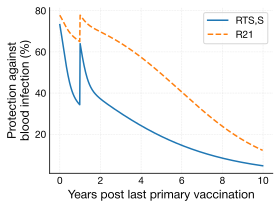

In [9]:
#| label: fig-imperial
#| fig-cap: "Imperial's estimated best fits of RTS,S and R21 vaccine protection profiles after the third dose of the primary course, as estimated from phase 3 data in children receiving their first dose between 5 and 17 months and a booster 12 months after the third dose. The R21 curve has been adjusted for possible bias."

fig, ax = summary.imperial_vaccine_protection()

# Blood-stage vaccine (RH5.1)

@fig-blood-vac illustrates the possible effects of a blood-stage vaccine on blood-stage infection and disease. The RH5.1 vaccine blocks merozoite invasion of erythrocytes thereby reducing parasite growth rate and parasitaemia at presentation. This may cause any of the following:

- reduced risk of a blood infection (similar to a pre-erythrocytic vaccine)
- reduced risk of a blood infection causing clinical symptoms 
- reduced risk of clinical symptoms becoming severe

:::{#fig-blood-vac}
![](Figures/blood_stage_vac.svg){height=30% fig-align="center"}

The possible effects of a blood-stage vaccine. 
:::

We were kindly given unpublished data from the phase 2b trial of the RH5.1/Matrix-M blood stage vaccine [@natama_safety_2024]. The vaccine was given to children aged 5–17 months in Nanoro, Burkina Faso. The trial had three arms: the control "rabies" arm with the rabies vaccine Rabivax-S, the "delayed" vaccine arm with regimen of RH5.1/Matrix-M at 0, 1, and 5 months and the "monthly" vaccine arm with regimen at 0, 1, and 2 months. Vaccinations were completed part way through the malaria season.

As we discuss in [Notebook S9](S9_RH5.ipynb) we are not able to separately quantify each of the above three reduction in risks because none of the animal or human vaccine data allows us to determine whether RH5.1 reduces the risk of blood infection or not.

Instead, we examine two extreme scenarios: one where RH5.1 reduces the risk of blood infection but not clinical malaria, and the other where RH5.1 reduces the risk of clinical malaria but not blood infection. The reality is probably somewhere in between. But by examining these two extremes we can robustly test our conclusions against this uncertainty.

The phase 2b trial dataset contains cumulative all-cause fevers for each arm ([@fig-cumulative_episodes]A) and cumulative fevers with detectable parasites by microscopy ([@fig-cumulative_episodes]B). The limit of detection in this trial was not particularly sensitive at about 70 parasites/μl. We only use the delayed vaccine arm in our model as the efficacy of the monthly vaccine arm is inferior. Using this data with some reasonable assumptions we calculate that, for the first scenario, RH5.1 reduces the risk of blood infection by `{python} f'{1-D_d/D_r:.0%}'`, and for the second scenario RH5.1 reduces the risk of a blood infection becoming clinical by `{python} f'{pars.ω_clinical:.0%}'` ([Notebook S9](S9_RH5.ipynb)). 

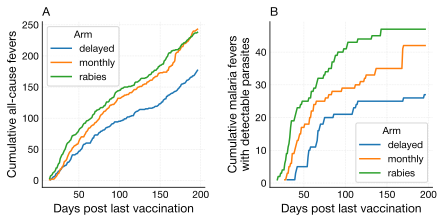

In [10]:
#| label: fig-cumulative_episodes
#| fig-cap: "A) Cumualtive all-cause fevers recorded either actively or passively for 200 days post last primary vaccination in the three trial arms of the phase 2b trial of the RH5.1/Matrix-M blood stage vaccine [@natama_safety_2024]. B) Cumulative clinical episodes (>0 parasites/μl by microscopy with fever in the last 24 h) in the three arms."

from Scripts import natama
fold_change = natama.fold_change()
fig, axs = natama.clinical_time_series()

Although there is no trial data on severe malaria episodes we can estimate the reduction in risk of a clinical episode becoming severe using the trial's parasitaemia data (@fig-parasitaemias). The delayed arm caused a `{python} f"{fold_change['delayed']:.1f}"` fold reduction in parasitaemia at presentation. Using the relationship between parasitaemia and the risk of clinical malaria becoming severe that we estimated using the data in @goncalves_parasite_2014 ([Notebook S4](S4_goncalves.ipynb)) we estimate that the delayed arm reduced the risk of clinical malaria becoming severe malaria by `{python} f'{pars.ω_severe:.0%}'` (see [Notebook S9](S9_RH5.ipynb)). 


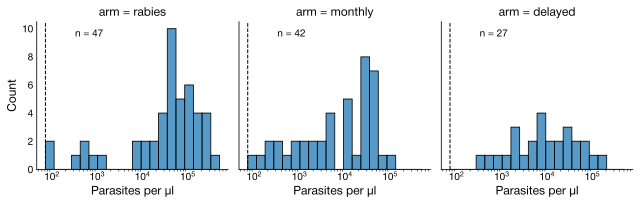

In [11]:
#| label: fig-parasitaemias
#| fig-cap: "Distributions of parasitaemia at presentation in each trial arm. The vertical dashed line in each panel is the smallest parasitaemia of 72 parasites/μl recorded across all episodes."

fig = natama.parasitaemia_distributions()

These reduction in risks are averaged over the trial's single malaria season. However, the protective profile of RH5.1 probably wanes rapidly over about six months based on anti-RH5.1 IgG antibody profiles [@silk_blood-stage_2024] (@fig-rh5_antibody_profiles). We use these profiles to model the waning efficacy of RH5.1 (see [Notebook S9](S9_RH5.ipynb)).

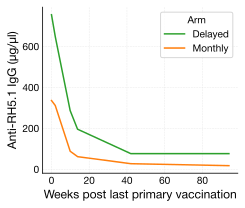

In [12]:
#| label: fig-rh5_antibody_profiles
#| fig-cap: "Median anti-RH5.1 IgG antibody profiles as measured by ELISA of the delayed and monthly arms reproduced from Figure S4 of @silk_blood-stage_2024. The profiles are from the 10D group of children two weeks after the last primary dose."

fig, ax = natama.rh5_antibody_profiles()

# Seasonal malaria chemoprevention

Seasonal malaria chemoprevention (SMC) is widely used in areas with highly seasonal transmission. It is given to young children monthly, four to five times during the peak season. SMC typically uses a combination of two drugs, sulfadoxine–pyrimethamine and amodiaquine. Amodiaquine has a relatively short half-life and is intended to quickly clear any existing malaria parasites in a child's system. Sulfadoxine–pyrimethamine has a longer half-life to prevent new infections for about 28 days [@zongo_seasonal_2024].

To parameterise SMC for our model we made use of five year phase 3 trial data from @chandramohan_seasonal_2021 and @dicko_seasonal_2024. See [Notebook S8](S8_SMC.ipynb) for more details. This was a trial of SMC-only, RTS,S-only and SMC+RTS,S combined, in two seasonal sites: Bougouni district in Mali and Hounde district, Burkina Faso. 

We tried fitting several different protection profiles for SMC against blood infection. We finally settled on one in which protection ramps up from the start of the season at some given rate, until it plateaus at a given coverage. It stays at this level until the end of four rounds (four months) at which point it returns to zero ([@fig-smc]). 

This model gave excellent fits to the trial data ([Notebook S8](S8_SMC.ipynb)). Other functional forms should prove equally likely so we make no assertions that this is the true protection profile. 

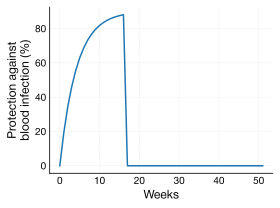

In [13]:
#| label: fig-smc
#| fig-cap: "Protection profile of SMC calibrated to five year phase 3 trial data from @chandramohan_seasonal_2021 and @dicko_seasonal_2024. Protection rises exponentially to a maximum of 90% coverage, then ceases after four months."

fig, ax = summary.SMC_protection()

# Mathematical description of the model

Let $\mu(a)$ be the natural non-malaria mortality rate of people of age $a$ weeks for $a=0,1,2 \dots$ (This Notebook).

Let $E_\text{infection}(a)$ be the early life protection profile against blood-stage infection for children of age $a$ ([Notebook S3](S3_season_length.ipynb)).

Let $L_\text{infection}(t)$ be the protection profile of a pre-erythrocytic vaccine, if given, against blood-stage infection in week $t$ post last primary dose, where $t=0,1,2,\dots$ (This Notebook). Let $B_\text{infection}(t)$ be the protection profile of a blood-stage vaccine, if given, against blood-stage infection in week $t$ ([Notebook S9](S9_RH5.ipynb)). Let $F_\text{infection}(t)$ be the protection profile of SMC, if given, against blood-stage infection in week $t$ ([Notebook S8](S8_SMC.ipynb)).

Let $\lambda$ be the annual average blood-stage infection rate experienced by the cohort. Let $s(t)$ be the seasonal modification to this rate such that $\sum_{t=0}^{51} s(t) = 1$ and $s(t)=s(t(\mod 52))$ ([Notebook S3](S3_season_length.ipynb)).

Let $b$ be a random variable that represents relative bite rate/susceptibility to blood-stage infection. The expected value of $b$ is 1.  

We assume that the four processes: early life protection; pre-erythrocytic vaccination; blood-stage vaccination and SMC, all act independently to reduce the risk of blood-stage infection. Therefore, the force of infection experienced by people of age $a$ with bite rate/susceptibility $b$, fully vaccinated $t$ weeks ago is

$$\Lambda(b,a,t) = \frac{b\lambda s(t)}{52}  [1-E_\text{infection}(a)][1-L_\text{infection}(t)][1-B_\text{infection}(t)][1-F_\text{infection}(t)]$$

The cohort of children that will receive their last primary vaccine dose at age $a_v$ weeks are simulated from $t=-a_v$ to $t=-1$ with $L_\text{infection}(t) = B_\text{infection}(t) =0$.

At $t=0$ children from ages $a_\text{min}$ to $a_\text{max}$ weeks receive their last primary vaccine dose. We assume that people can have at most 1 infection per week. Therefore, the cohort of people of age $a$ have from 0 to $a$ infections.

Therefore at a given time $t$, the youngest cohort will be $a_\text{min}+t$ weeks old and have from 0 to $a_\text{min}+t$ infections. The oldest cohort will be $a_\text{max}+t$ weeks old and have from 0 to $a_\text{max}+t$ infections.

Let $N(n-1,b,a-1,t-1)$ be the number of people of age $a-1$ weeks with $n-1$ infections and bite rate/susceptibility $b$ in week $t-1$.

In the next week, $t$, a proportion $\mu(a)$, will die of non-malaria causes and the surviving will experience a force of infection of $\Lambda(b,a,t)$. Then the expected number of new blood-stage infections in these people, $I(n,b,a,t)$ is

$$I(n,b,a,t) = [1-\mu(a)] \Lambda(b,a,t) N(n-1,b,a-1,t-1)$$

Let $P_\text{clinical}(n)$ be the naturally acquired protection against a blood-infection becoming clinical in people who have experienced $n$ blood-stage infections ([Notebook S5](S5_clinical_immunity.ipynb)). Let $B_\text{clinical}(t)$ be the protection profile of a blood-stage vaccine against a blood-stage infection becoming clinical in week $t$ ([Notebook S9](S9_RH5.ipynb)). Assuming these two processes act independently, the expected number of new clinical episodes in these people is

$$C(n,b,a,t) = [1-P_\text{clinical}(n)][1-B_\text{clinical}(t)] I(n,b,a,t)$$

Let $P_\text{severe}(n,a)$ be the naturally acquired protection against clinical malaria becoming severe in people of age $a$ who have experienced $n$ blood-stage infections ([Notebooks S4](S4_goncalves.ipynb) and [S6](S6_severe_malaria_immunity.ipynb)). Let $B_\text{severe}(t)$ be the protective profile of a blood-stage vaccine against a clinical episode becoming severe in week $t$ ([Notebook S9](S9_RH5.ipynb)). Assuming these two processes act independently, the expected number of clinical episodes that become severe in these people is

$$S(n,b,a,t) = [1-P_\text{severe}(n, a)][1-B_\text{severe}(t)] C(n,b,a,t)$$

Let $R_\text{death}(a)$ be the severe-case fatality risk of people of age $a$ ([Notebook S7](S7_cfr.ipynb)). Therefore the expected number of deaths in these people is

$$D(n,b,a,t) = R_\text{death}(a)  S(n,b,a,t)$$

Model output is, for each week, the number of new blood-stage infections, number of clinical episodes that do not become severe, number of severe episodes and number of deaths.

Finally we update the number of people of age $a=a_\text{min}+t, \dots, a_\text{max}+t$ weeks experiencing bite rate $b$ in week $t$:

$$
\begin{align*}
N(0,b,a,t) &= [1-\mu(a)]N(0,b,a-1,t-1) - I(1,b,a,t)\ \text{for $n=0$} \\
N(n,b,a,t) &= [1-\mu(a)]N(n,b,a-1,t-1) - I(n+1,b,a,t) + I(n,b,a,t) - D(n,b,a,t)\ \text{for $n=1\dots,a-1$} \\
N(a,b,a,t) &= I(n,b,a,t) - D(n,b,a,t)\ \text{for $n=a$} \\
\end{align*}
$$


::: {#refs}
:::